# Used Car Price Analysis & Prediction

중고차 데이터를 활용하여 차량 가격에 영향을 미치는 요인을 탐색하고,
머신러닝 모델을 이용해 중고차 판매 가격을 예측하는 프로젝트입니다.

데이터 전처리와 탐색적 데이터 분석(EDA)을 수행한 뒤,
Linear Regression과 Random Forest 모델의 성능을 비교했습니다.

## 1. Data Loading

먼저 데이터셋을 불러오고 컬럼과 데이터 구조를 확인합니다.

주요 변수는 다음과 같습니다.

- `year`: 차량 연식
- `selling_price`: 판매 가격
- `km_driven`: 주행거리
- `fuel`: 연료 종류
- `seller_type`: 판매자 유형
- `transmission`: 변속기 종류
- `owner`: 소유 이력

In [3]:
import pandas as pd

df = pd.read_csv("car_data.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [5]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')

In [6]:
high_mileage = df[df["km_driven"] >= 100000]

high_mileage.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
11,Tata Indigo Grand Petrol,2014,250000,100000,Petrol,Individual,Manual,First Owner
15,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner


In [7]:
df["km_driven"] >= 100000

0       False
1       False
2        True
3       False
4        True
        ...  
4335    False
4336    False
4337    False
4338    False
4339    False
Name: km_driven, Length: 4340, dtype: bool

In [8]:
len(high_mileage)


900

In [9]:
high_mileage.head().mean

<bound method DataFrame.mean of                         name  year  selling_price  km_driven    fuel  \
2       Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
4      Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   
5       Maruti Alto LX BSIII  2007         140000     125000  Petrol   
11  Tata Indigo Grand Petrol  2014         250000     100000  Petrol   
15      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   

   seller_type transmission         owner  
2   Individual       Manual   First Owner  
4   Individual       Manual  Second Owner  
5   Individual       Manual   First Owner  
11  Individual       Manual   First Owner  
15  Individual       Manual   First Owner  >

In [10]:
high_mileage["km_driven"].mean()

np.float64(132535.54111111112)

In [11]:
df["selling_price"].mean()

np.float64(504127.3117511521)

In [12]:
overall_mean = df["selling_price"].mean()
high_mileage_mean = high_mileage["selling_price"].mean()

In [13]:
diff = overall_mean - high_mileage_mean
diff

np.float64(142680.55730670766)

In [14]:
print(overall_mean)
print(high_mileage_mean)
print(diff)

504127.3117511521
361446.75444444444
142680.55730670766


In [15]:
high_mileage = df[df["km_driven"] >= 100000]

print(len(high_mileage))
print(high_mileage["selling_price"].mean())

900
361446.75444444444


In [16]:
percentage_diff = diff / overall_mean * 100

percentage_diff

np.float64(28.302485102639668)

In [17]:
df["fuel"].unique()

<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str

In [18]:
df.groupby("fuel")["selling_price"].mean()


fuel
CNG         277174.925000
Diesel      669094.252206
Electric    310000.000000
LPG         167826.043478
Petrol      344840.137541
Name: selling_price, dtype: float64

In [19]:
df["fuel"].value_counts()


fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

In [20]:
df.groupby("fuel")["selling_price"].median()

fuel
CNG         247500.0
Diesel      500000.0
Electric    310000.0
LPG         180000.0
Petrol      269000.0
Name: selling_price, dtype: float64

In [21]:
df.groupby("fuel")["selling_price"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
fuel,,,,,
CNG,40,277174.925000,247500.0,45000,595000
Diesel,2153,669094.252206,500000.0,45000,8150000
Electric,1,310000.000000,310000.0,310000,310000
LPG,23,167826.043478,180000.0,50000,290000
Petrol,2123,344840.137541,269000.0,20000,8900000


In [22]:
df.sort_values("selling_price", ascending=False).head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3872,Audi RS7 2015-2019 Sportback Performance,2016,8900000,13000,Petrol,Dealer,Automatic,First Owner
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,2017,8150000,6500,Diesel,Dealer,Automatic,First Owner
3969,Mercedes-Benz GLS 2016-2020 350d 4MATIC,2016,5500000,77350,Diesel,Dealer,Automatic,First Owner
2739,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
612,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
2239,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
555,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
593,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
1023,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
919,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner


## 2. Data Cleaning

데이터를 확인한 결과 중복된 행이 존재했습니다.

중복 데이터는 특정 차량이나 가격대가 실제보다 많이 반영되어
분석 결과에 영향을 줄 수 있기 때문에 제거한 후 분석을 진행했습니다.

원본 데이터는 `df`에 유지하고,
중복을 제거한 데이터는 `df_clean`에 저장했습니다.

In [23]:
df.duplicated().sum()

np.int64(763)

In [24]:
df_clean = df.drop_duplicates()

In [25]:
len(df_clean)

3577

In [26]:
df_clean.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis

중고차 가격과 각 변수 사이의 관계를 확인합니다.

주행거리, 연식, 연료 종류, 변속기, 브랜드, 소유 이력 등이
판매 가격과 어떤 관계를 가지는지 분석했습니다.

In [27]:
df_clean.groupby("fuel")["selling_price"].mean()


fuel
CNG         273162.081081
Diesel      614001.075000
Electric    310000.000000
LPG         171818.136364
Petrol      335344.340128
Name: selling_price, dtype: float64

In [28]:
high_mileage = df_clean[df_clean["km_driven"] >= 100000]

In [29]:
len(high_mileage)

811

In [30]:
overall_mean_clean = df_clean["selling_price"].mean()

In [31]:
high_mileage_mean_clean = high_mileage["selling_price"].mean()

In [32]:
print(overall_mean_clean)
print(high_mileage_mean_clean)

473912.54207436397
360595.663378545


In [33]:
difference_clean = overall_mean_clean - high_mileage_mean_clean
print(difference_clean)

113316.87869581894


In [34]:
percentage_difference_clean = difference_clean / overall_mean_clean * 100

percentage_difference_clean

np.float64(23.91092630716615)

In [35]:
import matplotlib.pyplot as plt

In [36]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [37]:
import matplotlib.pyplot as plt

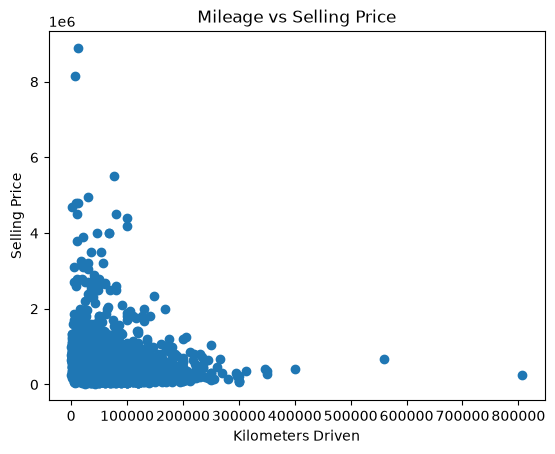

In [38]:
plt.scatter(df_clean["km_driven"], df_clean["selling_price"])
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Mileage vs Selling Price")
plt.show()

### Mileage vs Price

주행거리와 판매 가격의 관계를 확인한 결과,
주행거리가 증가할수록 가격이 낮아지는 경향이 나타났습니다.

상관계수는 약 -0.19로 강한 관계는 아니었지만,
약한 음의 상관관계를 확인할 수 있었습니다.

이는 중고차 가격이 주행거리 하나만으로 결정되지 않고
연식, 브랜드, 차종 등 다른 변수의 영향도 크게 받기 때문이라고 볼 수 있습니다.

In [39]:
correlation = df_clean["km_driven"].corr(df_clean["selling_price"])

correlation

np.float64(-0.18735891936683882)

In [40]:
year_corr = df_clean["year"].corr(df_clean["selling_price"])

year_corr

np.float64(0.4242600815426958)

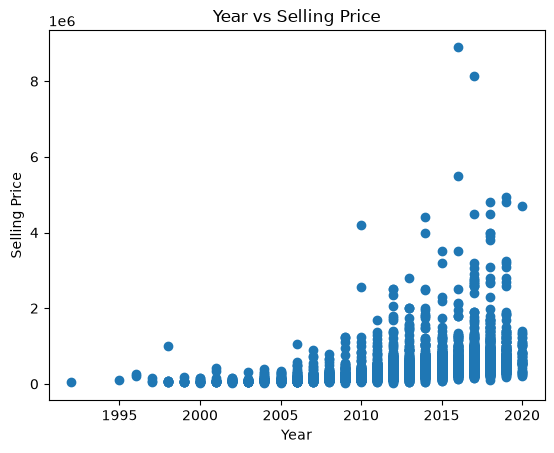

In [41]:
plt.scatter(df_clean["year"], df_clean["selling_price"])
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.title("Year vs Selling Price")
plt.show()

### Year vs Price

연식과 판매 가격의 상관계수는 약 0.42로 나타났습니다.

따라서 비교적 최근 연식의 차량일수록
판매 가격이 높은 경향이 있음을 확인했습니다.

In [42]:
df_clean["transmission"].value_counts()

transmission
Manual       3265
Automatic     312
Name: count, dtype: int64

In [43]:
df_clean.groupby("transmission")["selling_price"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
transmission,,,,,
Automatic,312,1.274955e+06,855000.0,79000,8900000
Manual,3265,3.973657e+05,325000.0,20000,1900000


In [44]:
df_clean.groupby("transmission")["year"].agg(
    ["count", "mean", "median"]
)


,count,mean,median
transmission,,,
Automatic,312,2014.567308,2016.0
Manual,3265,2012.809188,2013.0


In [45]:
cars_2018 = df_clean[df_clean["year"] == 2018]

In [46]:
cars_2018["transmission"].value_counts()
          

transmission
Manual       243
Automatic     52
Name: count, dtype: int64

In [47]:
cars_2018.groupby("transmission")["selling_price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
transmission,,,
Automatic,52,1.486846e+06,1100000.0
Manual,243,6.778107e+05,650000.0


In [48]:
df_clean["name"].iloc[0]

'Maruti 800 AC'

In [49]:
car_name = df_clean["name"].iloc[0]
car_name.split()

['Maruti', '800', 'AC']

In [50]:
car_name.split()[0]

'Maruti'

In [51]:
df_clean["brand"] = df_clean["name"].str.split().str[0]

In [52]:
df_clean["brand"].head()

0     Maruti
1     Maruti
2    Hyundai
3     Datsun
4      Honda
Name: brand, dtype: object

In [53]:
df_clean["brand"].value_counts()

brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Jaguar              5
Mitsubishi          5
Land                5
Volvo               4
Jeep                3
Ambassador          3
MG                  2
OpelCorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64

In [54]:
df_clean.groupby("brand")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
brand,,,
Land,5,3.609800e+06,4000000.0
Volvo,4,2.556250e+06,1987500.0
Mercedes-Benz,21,2.299238e+06,1451000.0
BMW,25,2.242800e+06,2150000.0
Audi,31,2.185452e+06,1580000.0
Jaguar,5,2.073000e+06,2000000.0
MG,2,1.842500e+06,1842500.0
Jeep,3,1.530000e+06,1490000.0
Isuzu,1,1.500000e+06,1500000.0


In [55]:
df_clean.loc[
    df_clean["name"].str.startswith("Land Rover"),
    "brand"
] = "Land Rover"

In [56]:
df_clean["brand"].value_counts().head(10)

brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Name: count, dtype: int64

In [57]:
brand_stats = df_clean.groupby("brand")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

brand_stats.head(10)

,count,mean,median
brand,,,
Land Rover,5,3.609800e+06,4000000.0
Volvo,4,2.556250e+06,1987500.0
Mercedes-Benz,21,2.299238e+06,1451000.0
BMW,25,2.242800e+06,2150000.0
Audi,31,2.185452e+06,1580000.0
Jaguar,5,2.073000e+06,2000000.0
MG,2,1.842500e+06,1842500.0
Jeep,3,1.530000e+06,1490000.0
Isuzu,1,1.500000e+06,1500000.0


In [58]:
brand_stats_20 = brand_stats[brand_stats["count"] >= 20]

brand_stats_20

,count,mean,median
brand,,,
Mercedes-Benz,21,2.299238e+06,1451000.0
BMW,25,2.242800e+06,2150000.0
Audi,31,2.185452e+06,1580000.0
Toyota,170,8.389176e+05,650000.0
Mahindra,328,5.847804e+05,532500.0
Ford,220,5.636272e+05,497500.0
Honda,216,5.399444e+05,495000.0
Skoda,49,4.755510e+05,400000.0
Volkswagen,93,4.616666e+05,400000.0


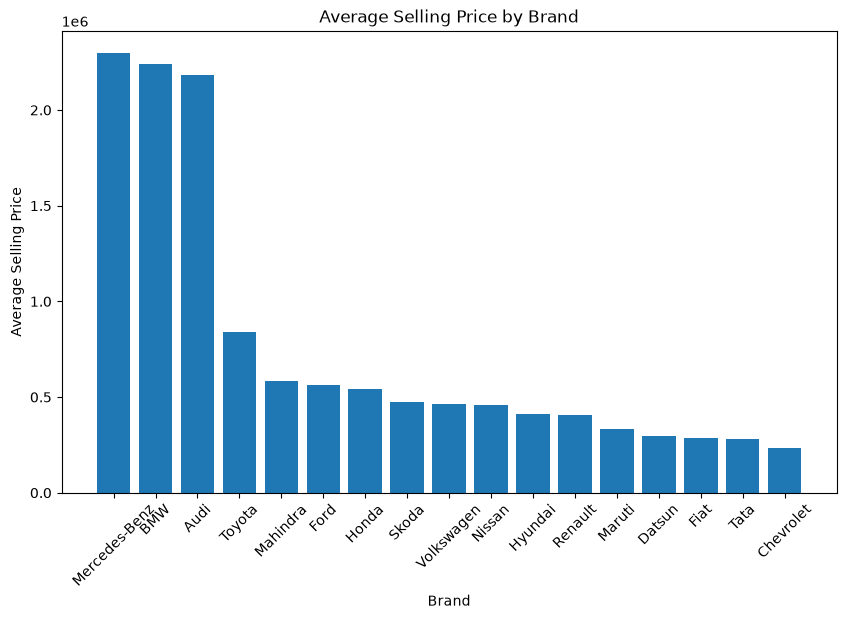

In [59]:
plt.figure(figsize=(10, 6))

plt.bar(
    brand_stats_20.index,
    brand_stats_20["mean"]
)

plt.xlabel("Brand")
plt.ylabel("Average Selling Price")
plt.title("Average Selling Price by Brand")

plt.xticks(rotation=45)

plt.show()

In [60]:
brand_transmission = pd.crosstab(
    df_clean["brand"],
    df_clean["transmission"],
    normalize="index"
) * 100

brand_transmission.loc[
    ["BMW", "Mercedes-Benz", "Audi", "Toyota"]
]


transmission,Automatic,Manual
brand,,
BMW,100.000000,0.000000
Mercedes-Benz,90.476190,9.523810
Audi,100.000000,0.000000
Toyota,11.764706,88.235294


In [61]:
toyota = df_clean[df_clean["brand"] == "Toyota"]

In [62]:
toyota.groupby("transmission")["selling_price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
transmission,,,
Automatic,20,1.891250e+06,1850000.0
Manual,150,6.986066e+05,595000.0


In [63]:
toyota.groupby("transmission")["year"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
transmission,,,
Automatic,20,2015.3,2017.0
Manual,150,2012.4,2012.0


In [64]:
pd.crosstab(
    toyota["year"],
    toyota["transmission"]
)

transmission,Automatic,Manual
year,,
2001,0,1
2003,1,0
2005,0,3
2006,1,4
2007,0,3
2008,0,5
2009,0,9
2010,1,10
2011,0,19


In [65]:
toyota_2017 = toyota[toyota["year"] == 2017]

In [66]:
toyota_2017.groupby("transmission")["selling_price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
transmission,,,
Automatic,8,2430625.0,2597500.0
Manual,7,1165000.0,1300000.0


In [67]:
toyota_2017[
    ["name", "transmission", "selling_price", "km_driven"]
].sort_values("transmission")

,name,transmission,selling_price,km_driven
527,Toyota Fortuner 2.8 4WD AT BSIV,Automatic,2750000,41000
563,Toyota Fortuner 4x2 AT,Automatic,2600000,47162
757,Toyota Innova Crysta 2.8 ZX AT BSIV,Automatic,1700000,75000
770,Toyota Fortuner 2.8 2WD AT BSIV,Automatic,2800000,20000
969,Toyota Camry 2.5 Hybrid,Automatic,1900000,20000
1290,Toyota Fortuner 2.8 2WD AT BSIV,Automatic,3200000,57000
1623,Toyota Fortuner 4x2 AT,Automatic,2595000,79641
2299,Toyota Camry Hybrid 2.5,Automatic,1900000,20118
771,Toyota Innova Crysta 2.4 ZX MT,Manual,1330000,91195
790,Toyota Etios Liva 1.4 VD,Manual,425000,36000


In [68]:
pd.crosstab(
    toyota_2017["name"].str.split().str[1],
    toyota_2017["transmission"]
)

transmission,Automatic,Manual
name,,
Camry,2,0
Etios,0,3
Fortuner,5,0
Innova,1,4


In [69]:
innova_2017 = toyota_2017[
    toyota_2017["name"].str.contains("Innova")
]

innova_2017[
    ["name", "transmission", "selling_price", "km_driven"]
]

,name,transmission,selling_price,km_driven
757,Toyota Innova Crysta 2.8 ZX AT BSIV,Automatic,1700000,75000
771,Toyota Innova Crysta 2.4 ZX MT,Manual,1330000,91195
975,Toyota Innova Crysta 2.4 VX MT BSIV,Manual,1770000,25000
1202,Toyota Innova Crysta 2.4 VX MT 8S BSIV,Manual,1900000,100000
1311,Toyota Innova Crysta 2.4 VX MT BSIV,Manual,1300000,70000


In [70]:
df_clean["owner"].value_counts()

owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Test Drive Car            17
Name: count, dtype: int64

In [71]:
df_clean.groupby("owner")["selling_price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
owner,,,
First Owner,2218,565385.447250,450000.0
Fourth & Above Owner,75,181213.293333,138000.0
Second Owner,978,341954.140082,267000.0
Test Drive Car,17,954293.941176,894999.0
Third Owner,289,266142.207612,190000.0


In [72]:
owner_order = [
    "First Owner",
    "Second Owner",
    "Third Owner",
    "Fourth & Above Owner"
]

In [73]:
owner_price = (
    df_clean[df_clean["owner"].isin(owner_order)]
    .groupby("owner")["selling_price"]
    .mean()
    .reindex(owner_order)
)

In [74]:
df_clean["owner"].isin(owner_order).value_counts()

owner
True     3560
False      17
Name: count, dtype: int64

In [75]:
owner_price

owner
First Owner             565385.447250
Second Owner            341954.140082
Third Owner             266142.207612
Fourth & Above Owner    181213.293333
Name: selling_price, dtype: float64

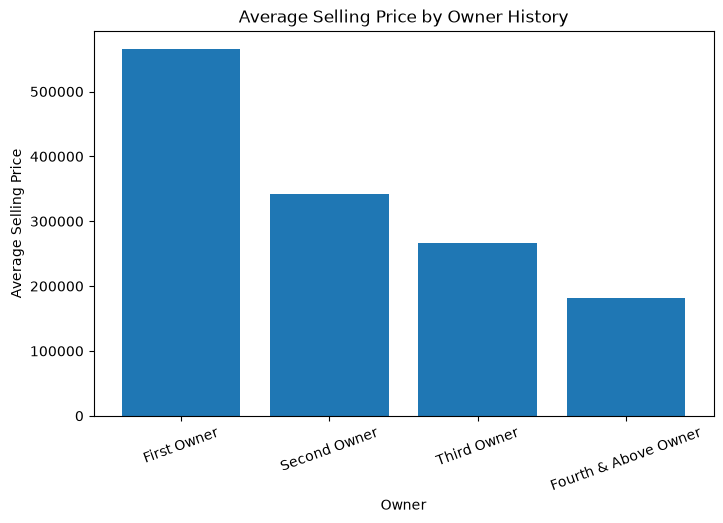

In [76]:
plt.figure(figsize=(8, 5))

plt.bar(
    owner_price.index,
    owner_price.values
)

plt.xlabel("Owner")
plt.ylabel("Average Selling Price")
plt.title("Average Selling Price by Owner History")

plt.xticks(rotation=20)

plt.show()

In [77]:
df_clean[df_clean["owner"].isin(owner_order)] \
    .groupby("owner")["year"] \
    .agg(["count", "mean", "median"]) \
    .reindex(owner_order)

,count,mean,median
owner,,,
First Owner,2218,2014.435528,2015.0
Second Owner,978,2010.960123,2011.0
Third Owner,289,2009.418685,2010.0
Fourth & Above Owner,75,2007.680000,2008.0


In [78]:
cars_2015 = df_clean[df_clean["year"] == 2015]

In [79]:
cars_2015["owner"].value_counts()

owner
First Owner             242
Second Owner             71
Third Owner              18
Fourth & Above Owner      1
Name: count, dtype: int64

In [80]:
owner_2015 = [
    "First Owner",
    "Second Owner",
    "Third Owner"
]

cars_2015[cars_2015["owner"].isin(owner_2015)] \
    .groupby("owner")["selling_price"] \
    .agg(["count", "mean", "median"]) \
    .reindex(owner_2015)

,count,mean,median
owner,,,
First Owner,242,522801.623967,470000.0
Second Owner,71,459943.577465,390000.0
Third Owner,18,556944.333333,415000.0


In [81]:
cars_2015[
    cars_2015["owner"] == "Third Owner"
].sort_values(
    "selling_price",
    ascending=False
)[["name", "selling_price", "km_driven"]]

,name,selling_price,km_driven
1410,Audi A4 35 TDI Premium,2300000,35000
1362,Toyota Innova 2.5 VX (Diesel) 7 Seater,1200000,70000
692,Mahindra XUV500 W6 2WD,825000,90000
4331,Ford EcoSport 1.5 TDCi Titanium BSIV,530000,175000
2978,Maruti Swift VDI BSIV,480000,140000
3540,Maruti Swift VDI BSIV,465000,60000
1578,Maruti Swift VDI BSIV,450000,70000
2125,Mahindra Xylo D2 BS IV,434999,100000
1683,Maruti Swift Dzire LDI,430000,73000
169,Maruti Swift VDI BSIV,400000,100000


In [82]:
third_owner_2015 = cars_2015[
    cars_2015["owner"] == "Third Owner"
]

third_owner_2015["selling_price"].mean()

np.float64(556944.3333333334)

In [83]:
third_owner_without_top = third_owner_2015[
    third_owner_2015["selling_price"] < 2300000
]

third_owner_without_top["selling_price"].mean()

np.float64(454411.64705882355)

### Transmission Analysis

Automatic 차량의 평균 가격이 Manual 차량보다 훨씬 높게 나타났습니다.

하지만 Automatic 차량은 평균적으로 더 최근 연식이었으며,
BMW, Audi, Mercedes-Benz 등 고가 브랜드의 Automatic 비율도 높았습니다.

따라서 단순히 'Automatic이기 때문에 가격이 높다'고 결론 내릴 수 없으며,
브랜드와 연식 같은 다른 변수의 영향이 함께 존재할 가능성이 있습니다.

In [84]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 4. Machine Learning

EDA 이후 차량 정보를 이용하여 판매 가격을 예측하는 모델을 구축했습니다.

먼저 단순한 기준 모델을 만들기 위해
`year`와 `km_driven` 두 변수만 사용한 Linear Regression을 학습했습니다.

데이터는 Train 80%, Test 20%로 분리했습니다.

In [85]:
X = df_clean[["year", "km_driven"]]
y = df_clean["selling_price"]

In [86]:
print(X.head())
print(y.head())

   year  km_driven
0  2007      70000
1  2007      50000
2  2012     100000
3  2017      46000
4  2014     141000
0     60000
1    135000
2    600000
3    250000
4    450000
Name: selling_price, dtype: int64


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [88]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2861, 2)
(716, 2)
(2861,)
(716,)


In [89]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [90]:
model.fit(X_train, y_train)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

LinearRegression()

In [ ]:
from sklearn import set_config

set_config(display="text")

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("예측 가격:")
print(y_pred[:5])

print("실제 가격:")
print(y_test.iloc[:5].values)

예측 가격:
[724006.11362694 673846.381696   622623.44386302 724126.93247946
 174170.08214132]
실제 가격:
[ 270000  525000  990000 3800000  229999]


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

236606.53350937937


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(r2)

0.16894770560727335


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 236606.53350937937
R²: 0.16894770560727335


### Baseline Linear Regression

첫 번째 모델은 `year`와 `km_driven`만 사용했습니다.

- MAE: 약 236,607
- R²: 약 0.169

연식과 주행거리만으로는 차량 가격의 차이를 충분히 설명하지 못했습니다.

따라서 브랜드, 연료, 변속기, 소유 이력 등의 변수를 추가했습니다.

In [ ]:
features = [
    "year",
    "km_driven",
    "brand",
    "fuel",
    "transmission",
    "owner",
    "seller_type"
]

X = df_clean[features]
y = df_clean["selling_price"]

In [ ]:
X.head()

,year,km_driven,brand,fuel,transmission,owner,seller_type
0,2007,70000,Maruti,Petrol,Manual,First Owner,Individual
1,2007,50000,Maruti,Petrol,Manual,First Owner,Individual
2,2012,100000,Hyundai,Diesel,Manual,First Owner,Individual
3,2017,46000,Datsun,Petrol,Manual,First Owner,Individual
4,2014,141000,Honda,Diesel,Manual,Second Owner,Individual


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
print(X_encoded.shape)
X_encoded.head()

(3577, 41)


,year,km_driven,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,brand_Force,brand_Ford,...,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,seller_type_Individual,seller_type_Trustmark Dealer
0,2007,70000,False,False,False,False,False,False,False,False,...,False,False,True,True,False,False,False,False,True,False
1,2007,50000,False,False,False,False,False,False,False,False,...,False,False,True,True,False,False,False,False,True,False
2,2012,100000,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,2017,46000,False,False,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,True,False
4,2014,141000,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,True,False


### Categorical Feature Encoding

브랜드, 연료, 변속기 등은 문자열 데이터이기 때문에
머신러닝 모델이 직접 사용할 수 없습니다.

따라서 One-Hot Encoding을 사용하여 범주형 변수를 숫자 형태로 변환했습니다.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model2 = LinearRegression()

model2.fit(X_train, y_train);

In [ ]:
y_pred2 = model2.predict(X_test)

In [ ]:
mae2 = mean_absolute_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print("MAE:", mae2)
print("R²:", r2_2)

MAE: 185413.76018351727
R²: 0.5510932901085877


### Linear Regression with Additional Features

추가 변수를 포함한 결과 모델 성능이 크게 향상되었습니다.

- MAE: 약 185,414
- R²: 약 0.551

이는 브랜드, 연료, 변속기, 소유 이력 등의 정보가
중고차 가격 예측에 중요한 역할을 한다는 것을 보여줍니다.

### Random Forest

Linear Regression은 변수와 가격 사이의 관계를 주로 선형적으로 학습합니다.

중고차 가격은 다양한 변수 사이의 복잡한 관계가 존재할 수 있기 때문에
비선형 관계를 학습할 수 있는 Random Forest 모델도 적용했습니다.

결과:

- MAE: 약 159,225
- R²: 약 0.586

Linear Regression보다 더 좋은 예측 성능을 보였습니다.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train);

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R²:", r2_rf)

Random Forest MAE: 159225.01979403576
Random Forest R²: 0.5859337415161134


In [ ]:
y_train_pred_rf = rf_model.predict(X_train)

train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_r2_rf = r2_score(y_train, y_train_pred_rf)

print("Train MAE:", train_mae_rf)
print("Train R²:", train_r2_rf)

print("Test MAE:", mae_rf)
print("Test R²:", r2_rf)

Train MAE: 62093.44608820872
Train R²: 0.9442483805340551
Test MAE: 159225.01979403576
Test R²: 0.5859337415161134


### Overfitting Check

기본 Random Forest의 성능을 Train과 Test 데이터에서 비교했습니다.

- Train R²: 약 0.944
- Test R²: 약 0.586

Train 성능에 비해 Test 성능이 크게 낮아
과적합 가능성이 있다고 판단했습니다.

In [ ]:
rf_model2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

rf_model2.fit(X_train, y_train);

In [ ]:
y_train_pred_rf2 = rf_model2.predict(X_train)
y_test_pred_rf2 = rf_model2.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred_rf2))
print("Train R²:", r2_score(y_train, y_train_pred_rf2))

print("Test MAE:", mean_absolute_error(y_test, y_test_pred_rf2))
print("Test R²:", r2_score(y_test, y_test_pred_rf2))

Train MAE: 117331.93008288615
Train R²: 0.7894249192922422
Test MAE: 158730.03664031092
Test R²: 0.5790323135088664


### Hyperparameter Tuning

Random Forest의 과적합을 줄이고 일반화 성능을 개선하기 위해
GridSearchCV를 사용하여 하이퍼파라미터를 탐색했습니다.

5-Fold Cross Validation을 사용했으며,
MAE를 기준으로 모델을 비교했습니다.

선택된 파라미터:

- `max_depth = 10`
- `min_samples_leaf = 1`

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [None, 10, 15, 20],
    "min_samples_leaf": [1, 2, 3, 5]
}

In [ ]:
grid_search = GridSearchCV(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train);

In [ ]:
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1}


In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
best_rf


RandomForestRegressor(max_depth=10, random_state=42)

In [ ]:
print("Best CV MAE:", -grid_search.best_score_)

Best CV MAE: 145654.27418662675


In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
y_train_pred_best = best_rf.predict(X_train)
y_test_pred_best = best_rf.predict(X_test)

print("Train MAE:",
      mean_absolute_error(y_train, y_train_pred_best))
print("Train R²:",
      r2_score(y_train, y_train_pred_best))

print("Test MAE:",
      mean_absolute_error(y_test, y_test_pred_best))
print("Test R²:",
      r2_score(y_test, y_test_pred_best))

Train MAE: 100075.5925093907
Train R²: 0.8984432422364055
Test MAE: 156146.30892562494
Test R²: 0.5924615727092578


In [ ]:
import pandas as pd

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(15)


transmission_Manual       0.261928
year                      0.228811
km_driven                 0.114602
fuel_Diesel               0.083574
brand_Audi                0.055456
brand_Land Rover          0.043032
brand_Toyota              0.039619
fuel_Petrol               0.037820
seller_type_Individual    0.017479
brand_BMW                 0.014415
brand_Mercedes-Benz       0.010549
brand_Jaguar              0.010164
brand_Maruti              0.009042
brand_Volvo               0.008321
brand_Mahindra            0.007867
dtype: float64

<Axes: >

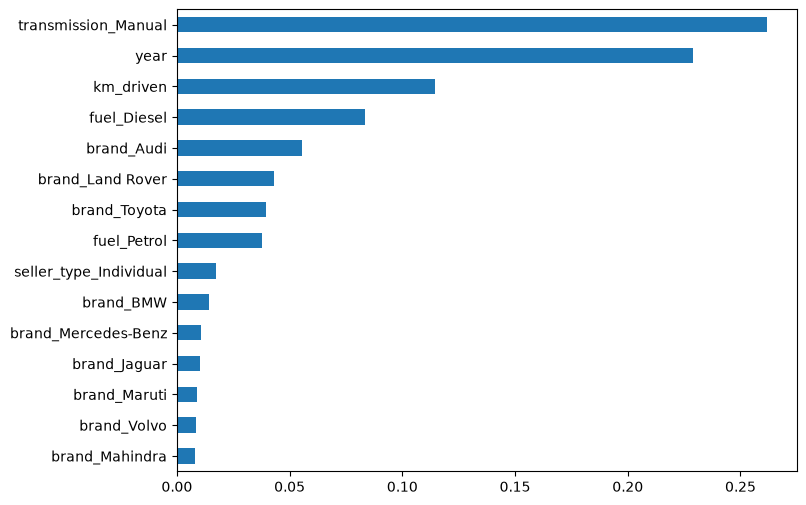

In [ ]:
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

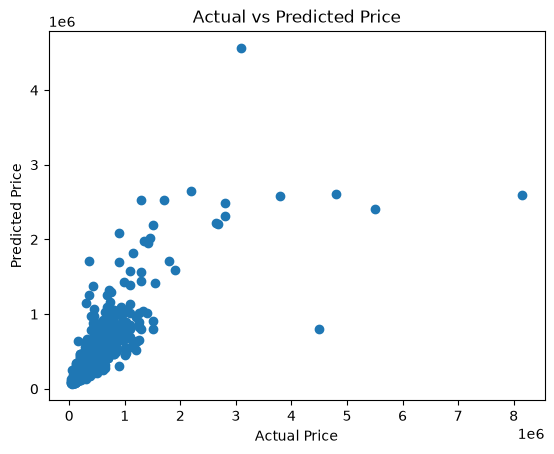

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_test_pred_best)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()


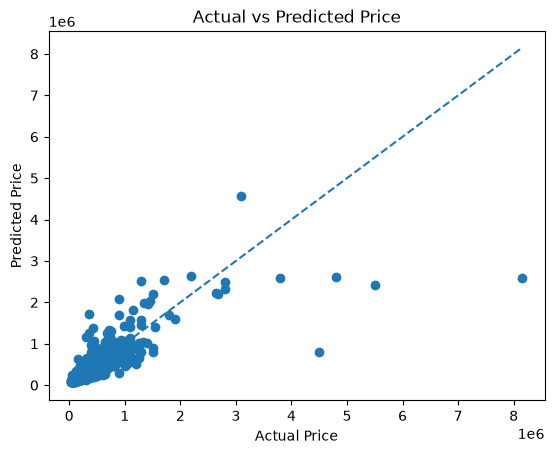

In [ ]:
plt.scatter(y_test, y_test_pred_best)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

In [ ]:
results = X_test.copy()

results["actual_price"] = y_test
results["predicted_price"] = y_test_pred_best

results["error"] = abs(
    results["actual_price"] - results["predicted_price"]
)


In [ ]:
results.sort_values(
    "error",
    ascending=False
).head(10)

,year,km_driven,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,brand_Force,brand_Ford,...,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,seller_type_Individual,seller_type_Trustmark Dealer,actual_price,predicted_price,error
89,2017,6500,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,8150000,2.596903e+06,5.553097e+06
101,2018,9800,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,4500000,7.990622e+05,3.700938e+06
3969,2016,77350,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,5500000,2.407712e+06,3.092288e+06
3453,2018,9422,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,4800000,2.609261e+06,2.190739e+06
1065,2018,22000,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,3100000,4.567270e+06,1.467270e+06
1067,2010,80000,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,False,350000,1.708344e+06,1.358344e+06
3046,2019,10000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,1300000,2.526182e+06,1.226182e+06
553,2018,10000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,3800000,2.580754e+06,1.219246e+06
38,2016,50000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,900000,2.087045e+06,1.187045e+06
4105,2020,1000,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,426000,1.374433e+06,9.484327e+05


In [ ]:
results["name"] = df_clean.loc[results.index, "name"]

In [ ]:
results.sort_values(
    "error",
    ascending=False
)[
    ["name", "actual_price", "predicted_price", "error"]
].head(10)

,name,actual_price,predicted_price,error
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,8150000,2.596903e+06,5.553097e+06
101,Mercedes-Benz E-Class Exclusive E 200 BSIV,4500000,7.990622e+05,3.700938e+06
3969,Mercedes-Benz GLS 2016-2020 350d 4MATIC,5500000,2.407712e+06,3.092288e+06
3453,BMW 5 Series 520d Luxury Line,4800000,2.609261e+06,2.190739e+06
1065,Audi A4 30 TFSI Technology,3100000,4.567270e+06,1.467270e+06
1067,Toyota Corolla Altis 1.8 VL AT,350000,1.708344e+06,1.358344e+06
3046,Kia Seltos HTK Plus AT D,1300000,2.526182e+06,1.226182e+06
553,Mercedes-Benz C-Class Progressive C 220d,3800000,2.580754e+06,1.219246e+06
38,Toyota Corolla Altis G AT,900000,2.087045e+06,1.187045e+06
4105,Tata Harrier XE,426000,1.374433e+06,9.484327e+05


### Final Model Performance

튜닝된 Random Forest의 최종 성능은 다음과 같습니다.

- Train MAE: 약 100,076
- Train R²: 약 0.898
- Test MAE: 약 156,146
- Test R²: 약 0.592

기본 Random Forest보다 과적합이 줄었으며,
Test 데이터에서도 소폭 개선된 성능을 확인했습니다.

## 6. Error Analysis

Actual Price와 Predicted Price를 비교한 결과,
일반적인 가격대에서는 비교적 잘 예측했지만
일부 고가 차량에서는 실제 가격을 크게 낮게 예측하는 경향이 나타났습니다.

가장 큰 오차가 발생한 차량에는
Mercedes-Benz S-Class, E-Class, GLS와 BMW 5 Series 등
고가 차량들이 포함되어 있었습니다.

현재 모델은 브랜드 정보는 사용하지만
세부 모델과 트림 정보를 충분히 활용하지 못하고 있기 때문에,
고급 차량의 가격 차이를 정확하게 구분하는 데 한계가 있는 것으로 보입니다.

## 7. Conclusion

이번 프로젝트에서는 중고차 데이터를 이용하여
데이터 전처리, 탐색적 데이터 분석, 머신러닝 모델링까지 진행했습니다.

Linear Regression에서 시작하여 Random Forest까지 모델을 확장했고,
Cross Validation과 Hyperparameter Tuning을 통해
모델의 일반화 성능을 개선했습니다.

최종 Random Forest 모델은 약 156,000의 MAE와
약 0.59의 R²를 기록했습니다.

### Limitations & Future Work

현재 데이터에는 차량의 세부 모델, 엔진, 옵션, 사고 이력 등
가격에 영향을 줄 수 있는 정보가 충분하지 않습니다.

향후에는 차량 이름에서 세부 모델 정보를 추출하거나,
더 다양한 특성을 추가하여 모델 성능을 개선할 수 있습니다.